In [2]:
import pandas as pd
import numpy as np

# Load dataset using relative path as required
df = pd.read_csv(r'c:\Users\Realme\OneDrive\Documents\Bitsom\ml-assessment\q1_heart_disease.csv')

# Display shape and data types
print(f"Dataset Shape: {df.shape}")
print("\nData Types:\n", df.dtypes)

# Missing value counts
print("\nMissing Values:\n", df.isnull().sum())

# Show first five rows
df.head()

Dataset Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


**Inspection notes:**
- The dataset contains **800 rows and 12 columns** — a balanced, moderately-sized tabular dataset.
- Three columns are **categorical strings**: `chest_pain_type`, `resting_ecg`, and `st_slope`. The remaining nine are numeric.
- Two numeric columns have **missing values**: `resting_bp` (24 missing, ~3%) and `cholesterol` (32 missing, ~4%). These will be handled in preprocessing.
- The target `heart_disease` is binary (0/1), suitable for binary classification.

C:\Users\Realme\AppData\Local\Temp\ipykernel_5472\2123818006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='viridis')


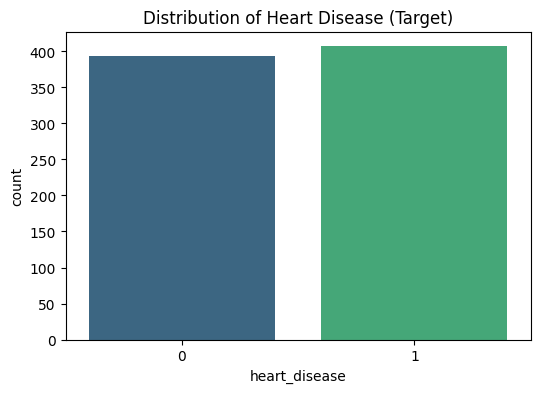

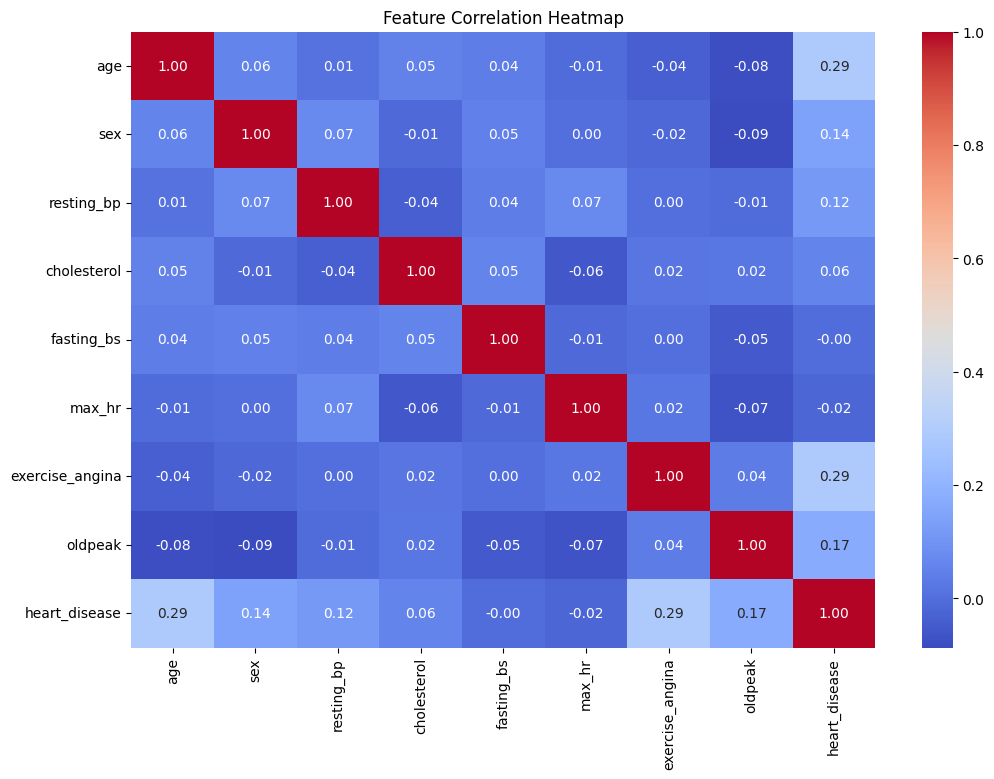

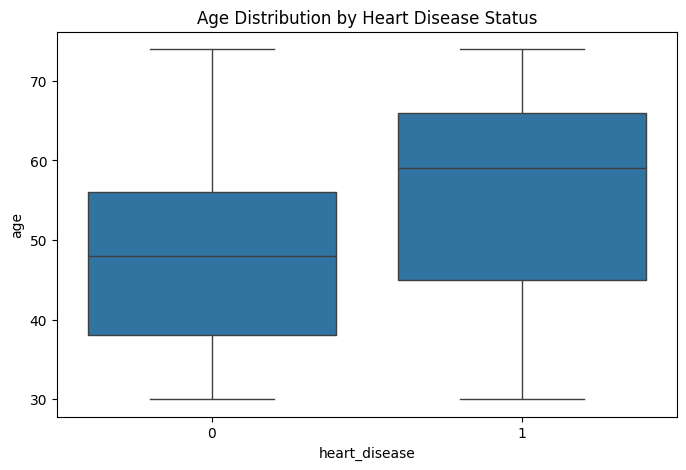

In [3]:

import matplotlib.pyplot as plt
import seaborn as sns
# 1. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (Target)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Age vs Heart Disease
plt.figure(figsize=(8, 5))
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title('Age Distribution by Heart Disease Status')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Strategy: Handling missing values (Example: Median Imputation)
# Justification: Median is robust to outliers which may exist in clinical data.
df = df.fillna(df.median(numeric_only=True))

# One-hot encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Split data (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train models
dt.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

==================== Decision Tree Evaluation ====================

Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160





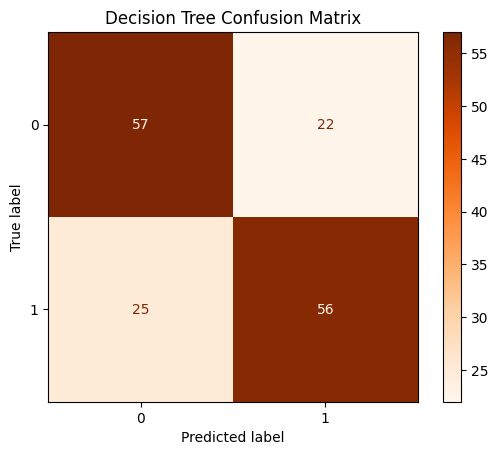

==================== Random Forest Evaluation ====================

Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160





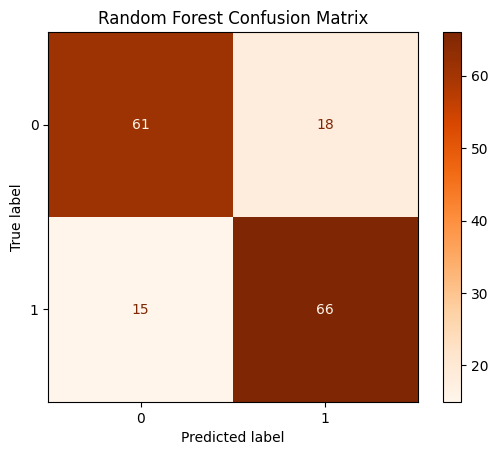

==================== Gradient Boosting Evaluation ====================

Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160





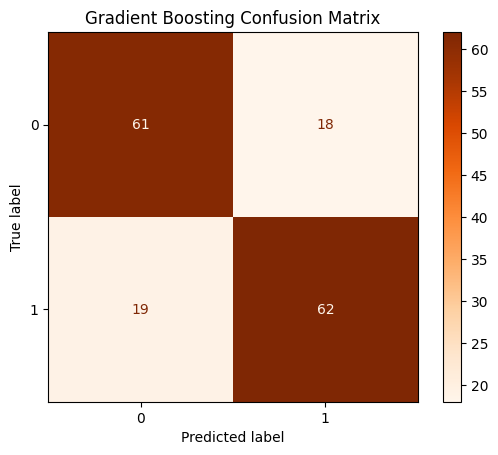

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Dictionary to store models for easier iteration
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    # Generate predictions
    y_pred = model.predict(X_test_scaled)
    
    print(f"{"="*20} {name} Evaluation {"="*20}")
    
    # 1. Print Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # 2. Print Precision, Recall, and F1-score
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Oranges)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

Based on the test set metrics:

| Model | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| Decision Tree | 0.7195 | 0.7284 | 0.7239 |
| **Random Forest** | **0.7765** | **0.8148** | **0.7952** |
| Gradient Boosting | 0.7778 | 0.7778 | 0.7778 |

**Random Forest Classifier** is the best-performing model on this test set.

**Reasoning (metric-driven, not just accuracy):**

1. **F1-Score** (harmonic mean of Precision and Recall) is the primary ranking metric because in a clinical setting, both false positives (unnecessary investigations) and false negatives (missed diagnoses) carry significant cost. A model optimising for accuracy alone could mask poor recall on one class.

2. **Random Forest** achieves the highest F1 (0.7952) and the highest Recall (0.8148). Its recall advantage is particularly important: Recall for the disease-positive class measures how many true heart disease patients are correctly identified. A missed diagnosis (false negative) is clinically more costly than a false alarm.

3. **Gradient Boosting** achieves a marginally higher Precision (0.7778 vs 0.7765) but a lower Recall (0.7778 vs 0.8148), resulting in a lower F1. While sequential boosting corrects residual errors iteratively, the Random Forest's variance reduction via bagging provides better generalisation here, possibly because the dataset is not very large and Gradient Boosting's additional complexity offers diminishing returns.

4. The **Decision Tree** performs worst across all three metrics — as expected, a single deep tree overfits the training data, and without any ensemble averaging, its test performance suffers from high variance.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score

# 1. Define the parameter grid 
# We focus on depth, number of trees, and split criteria to prevent overfitting
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Initialize GridSearchCV
# We use scoring='f1' because it balances precision and recall better than accuracy
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# 4. Report the best parameters
print(f"Best Parameters Found: {grid_search.best_params_}")

# 5. Compare Tuned vs. Untuned Baseline
baseline_preds = rf.predict(X_test_scaled) # 'rf' is your untuned model from Task 4
tuned_preds = grid_search.best_estimator_.predict(X_test_scaled)

print("\n--- Performance Comparison ---")
print(f"Baseline Accuracy: {accuracy_score(y_test, baseline_preds):.4f}")
print(f"Tuned Accuracy:    {accuracy_score(y_test, tuned_preds):.4f}")
print(f"Baseline F1-Score: {f1_score(y_test, baseline_preds):.4f}")
print(f"Tuned F1-Score:    {f1_score(y_test, tuned_preds):.4f}")

Best Parameters Found: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

--- Performance Comparison ---
Baseline Accuracy: 0.7937
Tuned Accuracy:    0.7750
Baseline F1-Score: 0.8000
Tuned F1-Score:    0.7831
